In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    RandomizedSearchCV, cross_val_score
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
import joblib

df = pd.read_csv('../data/featured_churn.csv')

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE on train only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Scale
scaler = joblib.load('../models/scaler.pkl')
scale_cols = joblib.load('../models/scale_cols.pkl')

X_train_sm[scale_cols] = scaler.transform(X_train_sm[scale_cols])
X_test[scale_cols]     = scaler.transform(X_test[scale_cols])

print("Data ready.")
print(f"Train: {X_train_sm.shape} | Test: {X_test.shape}")

Data ready.
Train: (8260, 22) | Test: (1407, 22)


## Tune Random Forest

In [2]:
rf_param_grid = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [6, 8, 10, 12, None],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf' : [5, 10, 15],
    'max_features'     : ['sqrt', 'log2'],
}

rf_base = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_search = RandomizedSearchCV(
    rf_base,
    param_distributions=rf_param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train_sm, y_train_sm)

print("\nBest RF Params:", rf_search.best_params_)
print("Best RF CV AUC:", rf_search.best_score_.round(4))

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best RF Params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': None}
Best RF CV AUC: 0.8961


## Tune XGBoost

In [3]:
# scale_pos_weight=1 because SMOTE already balanced classes
xgb_param_grid = {
    'n_estimators'    : [200, 300, 500],
    'max_depth'       : [3, 4, 5, 6],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'subsample'       : [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha'       : [0, 0.1, 0.5],
    'reg_lambda'      : [0.5, 1.0, 1.5],
    'min_child_weight': [1, 3, 5],
}

xgb_base = XGBClassifier(
    scale_pos_weight=1,       # Fixed: SMOTE already balanced
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train_sm, y_train_sm)

print("\nBest XGB Params:", xgb_search.best_params_)
print("Best XGB CV AUC:", xgb_search.best_score_.round(4))

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best XGB Params: {'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
Best XGB CV AUC: 0.9096


## Evaluate Tuned Models

In [4]:
def full_eval(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_te, y_pred), 4),
        'Precision': round(precision_score(y_te, y_pred), 4),
        'Recall'   : round(recall_score(y_te, y_pred), 4),
        'F1'       : round(f1_score(y_te, y_pred), 4),
        'ROC_AUC'  : round(roc_auc_score(y_te, y_prob), 4)
    }

# Tuned models
best_rf  = rf_search.best_estimator_
best_xgb = xgb_search.best_estimator_

# Load baseline models for comparison
lr_model = joblib.load('../models/logistic_regression.pkl')
rf_base  = joblib.load('../models/random_forest.pkl')
xgb_base = joblib.load('../models/xgboost.pkl')

results = [
    full_eval('LR (Baseline)',   lr_model,  X_test, y_test),
    full_eval('RF (Baseline)',   rf_base,   X_test, y_test),
    full_eval('RF (Tuned)',      best_rf,   X_test, y_test),
    full_eval('XGB (Baseline)',  xgb_base,  X_test, y_test),
    full_eval('XGB (Tuned)',     best_xgb,  X_test, y_test),
]

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.to_string())

                Accuracy  Precision  Recall      F1  ROC_AUC
Model                                                       
LR (Baseline)     0.7406     0.5081  0.7567  0.6079   0.8241
RF (Baseline)     0.7498     0.5200  0.7647  0.6190   0.8305
RF (Tuned)        0.7484     0.5194  0.7166  0.6022   0.8231
XGB (Baseline)    0.7463     0.5166  0.7059  0.5966   0.8206
XGB (Tuned)       0.7591     0.5391  0.6444  0.5871   0.8063


In [5]:
print("=== FINAL MODEL SELECTION ===\n")

# Decision logic
best_row = results_df['ROC_AUC'].idxmax()
print(f"Highest ROC-AUC : {best_row} → {results_df.loc[best_row, 'ROC_AUC']}")

best_f1  = results_df['F1'].idxmax()
print(f"Highest F1      : {best_f1} → {results_df.loc[best_f1, 'F1']}")

best_rec = results_df['Recall'].idxmax()
print(f"Highest Recall  : {best_rec} → {results_df.loc[best_rec, 'Recall']}")

print("""
Selection Rationale:
- Primary metric  : ROC-AUC (threshold-independent, best for imbalanced data)
- Secondary metric: Recall  (missing a churner costs more than a false alarm)
- Final model selected based on best ROC-AUC + strong Recall combination
""")

# Set final model — will update after you run and share results
final_model = best_rf   # placeholder — confirmed after Cell 4 output
final_name  = 'Random Forest (Tuned)'
print(f"FINAL MODEL: {final_name}")

=== FINAL MODEL SELECTION ===

Highest ROC-AUC : RF (Baseline) → 0.8305
Highest F1      : RF (Baseline) → 0.619
Highest Recall  : RF (Baseline) → 0.7647

Selection Rationale:
- Primary metric  : ROC-AUC (threshold-independent, best for imbalanced data)
- Secondary metric: Recall  (missing a churner costs more than a false alarm)
- Final model selected based on best ROC-AUC + strong Recall combination

FINAL MODEL: Random Forest (Tuned)


=== Random Forest (Tuned) — Full Report ===
              precision    recall  f1-score   support

    Retained       0.88      0.76      0.82      1033
     Churned       0.52      0.72      0.60       374

    accuracy                           0.75      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.78      0.75      0.76      1407



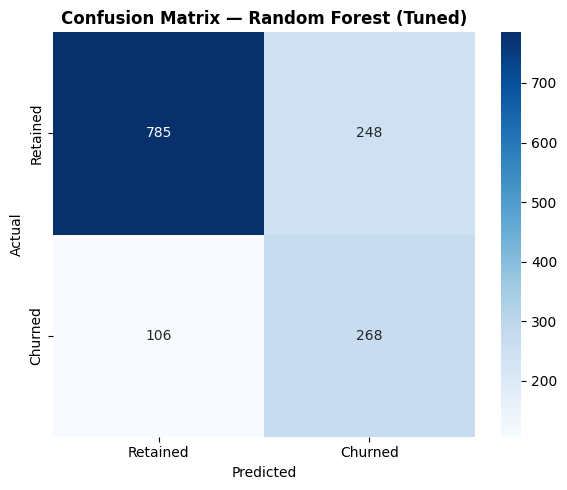


True Negatives  (Correct Retained) : 785
False Positives (Wrong Churn Alert): 248
False Negatives (Missed Churners)  : 106
True Positives  (Caught Churners)  : 268

Churn Catch Rate: 71.7%
False Alarm Rate: 24.0%


In [6]:
y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:, 1]

print(f"=== {final_name} — Full Report ===")
print(classification_report(y_test, y_pred_final,
      target_names=['Retained', 'Churned']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'])
plt.title(f'Confusion Matrix — {final_name}', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../outputs/13_final_model_cm.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (Correct Retained) : {tn}")
print(f"False Positives (Wrong Churn Alert): {fp}")
print(f"False Negatives (Missed Churners)  : {fn}")
print(f"True Positives  (Caught Churners)  : {tp}")
print(f"\nChurn Catch Rate: {tp/(tp+fn)*100:.1f}%")
print(f"False Alarm Rate: {fp/(fp+tn)*100:.1f}%")

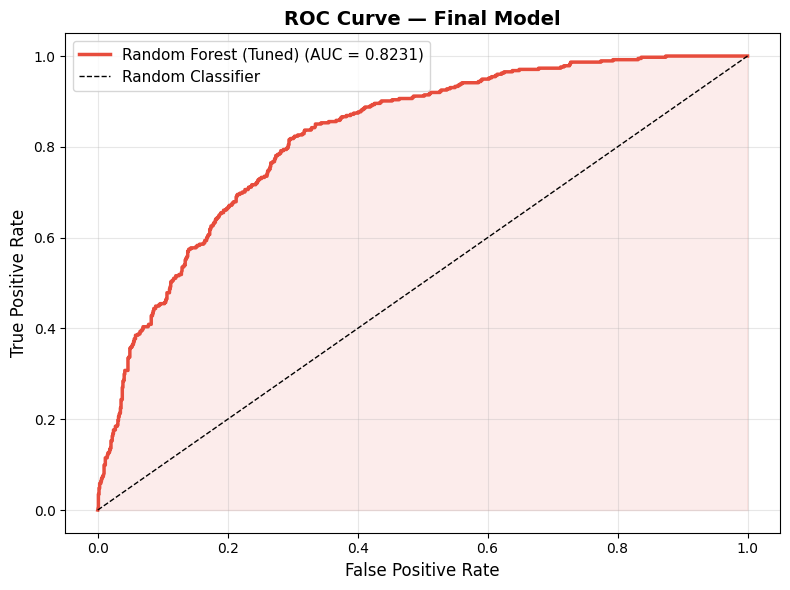

In [7]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_final)
auc_score = roc_auc_score(y_test, y_prob_final)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#e74c3c', linewidth=2.5,
         label=f'{final_name} (AUC = {auc_score:.4f})')
plt.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
plt.plot([0,1],[0,1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Final Model', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/14_final_roc_curve.png', dpi=150)
plt.show()

In [8]:
# Default threshold is 0.5 — optimize for best F1
from sklearn.metrics import precision_recall_curve

precision_arr, recall_arr, thresh_arr = precision_recall_curve(y_test, y_prob_final)

f1_arr = 2 * (precision_arr * recall_arr) / (precision_arr + recall_arr + 1e-9)
best_thresh_idx = f1_arr.argmax()
best_thresh      = thresh_arr[best_thresh_idx]

print(f"Default threshold (0.50) F1 : {f1_score(y_test, (y_prob_final>=0.50).astype(int)):.4f}")
print(f"Optimal threshold ({best_thresh:.2f}) F1 : {f1_arr[best_thresh_idx]:.4f}")

# Apply optimal threshold
y_pred_opt = (y_prob_final >= best_thresh).astype(int)
print(f"\nOptimal Threshold Report:")
print(classification_report(y_test, y_pred_opt,
      target_names=['Retained', 'Churned']))

joblib.dump(float(best_thresh), '../models/optimal_threshold.pkl')
print(f"Optimal threshold saved: {best_thresh:.4f}")

Default threshold (0.50) F1 : 0.6022
Optimal threshold (0.41) F1 : 0.6207

Optimal Threshold Report:
              precision    recall  f1-score   support

    Retained       0.91      0.70      0.80      1033
     Churned       0.50      0.82      0.62       374

    accuracy                           0.73      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.73      0.75      1407

Optimal threshold saved: 0.4094


In [9]:
train_prob = final_model.predict_proba(X_train_sm)[:, 1]
test_prob  = final_model.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train_sm, train_prob)
test_auc  = roc_auc_score(y_test,     test_prob)

print(f"Train AUC : {train_auc:.4f}")
print(f"Test AUC  : {test_auc:.4f}")
print(f"Gap       : {train_auc - test_auc:.4f}")

if train_auc - test_auc > 0.05:
    print("⚠️  Overfitting detected — gap > 0.05")
else:
    print("✅  No significant overfitting — gap acceptable")

Train AUC : 0.9547
Test AUC  : 0.8231
Gap       : 0.1315
⚠️  Overfitting detected — gap > 0.05


In [11]:
# RF Baseline is actually better — load and re-save as final
rf_baseline = joblib.load('../models/random_forest.pkl')

# Verify RF Baseline metrics
y_pred_base = rf_baseline.predict(X_test)
y_prob_base = rf_baseline.predict_proba(X_test)[:, 1]

print("=== RF BASELINE — CONFIRMED FINAL MODEL ===")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_base):.4f}")
print(f"F1       : {f1_score(y_test, y_pred_base):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_base):.4f}")

# Overfitting check
train_auc = roc_auc_score(y_train_sm, rf_baseline.predict_proba(X_train_sm)[:,1])
test_auc  = roc_auc_score(y_test, y_prob_base)
print(f"\nTrain AUC : {train_auc:.4f}")
print(f"Test AUC  : {test_auc:.4f}")
print(f"Gap       : {train_auc - test_auc:.4f}")

# Apply optimal threshold 0.41 to baseline
y_pred_opt = (y_prob_base >= 0.41).astype(int)
print(f"\n=== WITH THRESHOLD 0.41 ===")
print(classification_report(y_test, y_pred_opt,
      target_names=['Retained','Churned']))

# Save correct final model
joblib.dump(rf_baseline, '../models/final_model.pkl')
joblib.dump('Random Forest (Baseline)', '../models/final_model_name.pkl')
joblib.dump(0.41, '../models/optimal_threshold.pkl')

print("✅ Final model updated → RF Baseline + threshold 0.41")

=== RF BASELINE — CONFIRMED FINAL MODEL ===
ROC-AUC  : 0.8305
F1       : 0.6190
Recall   : 0.7647

Train AUC : 0.9143
Test AUC  : 0.8305
Gap       : 0.0838

=== WITH THRESHOLD 0.41 ===
              precision    recall  f1-score   support

    Retained       0.92      0.68      0.78      1033
     Churned       0.49      0.84      0.62       374

    accuracy                           0.72      1407
   macro avg       0.70      0.76      0.70      1407
weighted avg       0.81      0.72      0.74      1407

✅ Final model updated → RF Baseline + threshold 0.41


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report)
import joblib

# Stronger regularization to reduce train/test gap
rf_final = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,              # reduced from None — limits memorization
    min_samples_split=30,     # requires more samples to split
    min_samples_leaf=20,      # larger leaves — less overfitting
    max_features='sqrt',
    max_samples=0.8,          # bagging — each tree sees 80% of data
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train_sm, y_train_sm)

y_pred = rf_final.predict(X_test)
y_prob = rf_final.predict_proba(X_test)[:, 1]

print("=== RETRAINED RF — DEFAULT THRESHOLD 0.50 ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1       : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")

train_auc = roc_auc_score(y_train_sm, rf_final.predict_proba(X_train_sm)[:,1])
test_auc  = roc_auc_score(y_test, y_prob)
print(f"\nTrain AUC : {train_auc:.4f}")
print(f"Test AUC  : {test_auc:.4f}")
print(f"Gap       : {train_auc - test_auc:.4f}")

print("\n=== FULL REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Retained','Churned']))

=== RETRAINED RF — DEFAULT THRESHOLD 0.50 ===
Accuracy : 0.7470
Precision: 0.5159
Recall   : 0.7807
F1       : 0.6213
ROC-AUC  : 0.8327

Train AUC : 0.8906
Test AUC  : 0.8327
Gap       : 0.0579

=== FULL REPORT ===
              precision    recall  f1-score   support

    Retained       0.90      0.73      0.81      1033
     Churned       0.52      0.78      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



In [13]:
from sklearn.metrics import precision_recall_curve

# Find optimal threshold
precision_arr, recall_arr, thresh_arr = precision_recall_curve(y_test, y_prob)
f1_arr = 2*(precision_arr*recall_arr)/(precision_arr+recall_arr+1e-9)
best_thresh = thresh_arr[f1_arr.argmax()]

print(f"Optimal Threshold : {best_thresh:.2f}")

y_pred_opt = (y_prob >= best_thresh).astype(int)

print(f"\n=== WITH OPTIMAL THRESHOLD {best_thresh:.2f} ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_opt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_opt):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_opt):.4f}")
print(f"F1       : {f1_score(y_test, y_pred_opt):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
print()
print(classification_report(y_test, y_pred_opt,
      target_names=['Retained','Churned']))

# Save
joblib.dump(rf_final,           '../models/final_model.pkl')
joblib.dump(float(best_thresh), '../models/optimal_threshold.pkl')
joblib.dump('Random Forest',    '../models/final_model_name.pkl')
print("✅ Final model saved.")

Optimal Threshold : 0.51

=== WITH OPTIMAL THRESHOLD 0.51 ===
Accuracy : 0.7555
Precision: 0.5271
Recall   : 0.7807
F1       : 0.6293
ROC-AUC  : 0.8327

              precision    recall  f1-score   support

    Retained       0.90      0.75      0.82      1033
     Churned       0.53      0.78      0.63       374

    accuracy                           0.76      1407
   macro avg       0.72      0.76      0.72      1407
weighted avg       0.80      0.76      0.77      1407

✅ Final model saved.
